In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


libraries

In [21]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [22]:
import os
import zipfile

zip_path = "/content/drive/MyDrive/apple_disease_classification.zip"
extract_path = "/content/dataset"

# Create the extraction directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Dataset extracted to: {extract_path}")

# Verify the extracted contents (optional, but good for debugging)
print("Contents of extracted directory:")
for root, dirs, files in os.walk(extract_path):
    print(f"Root: {root}, Dirs: {dirs}, Files: {files}")
    # Only show top-level for brevity if needed, or adjust depth
    if root == extract_path: # only show one level deep
        break

Dataset extracted to: /content/dataset
Contents of extracted directory:
Root: /content/dataset, Dirs: ['apple_disease_classification'], Files: []


CHECK FOLDER STRUCTURE

In [23]:
for root, dirs, files in os.walk(extract_path):
    print("Folders:", dirs)
    break

Folders: ['apple_disease_classification']


count training and testing image

In [24]:
import os

# Define path to your Training folder
train_path = '/content/dataset/apple_disease_classification/Train'

def count_train(path):
    if not os.path.exists(path):
        return "Error: Path not found. Make sure you unzipped or mounted your drive correctly."

    count = sum([len(files) for r, d, files in os.walk(path) if any(f.lower().endswith(('.png', '.jpg', '.jpeg')) for f in files)])
    return f"Total Training Images: {count}"

print(count_train(train_path))

Total Training Images: 382


In [25]:
import os

# Define path to your Test folder
test_path = '/content/dataset/apple_disease_classification/Test'

def count_test(path):
    if not os.path.exists(path):
        return "Error: Path not found. Check if the folder name is 'Test' or 'Validation'."

    count = sum([len(files) for r, d, files in os.walk(path) if any(f.lower().endswith(('.png', '.jpg', '.jpeg')) for f in files)])
    return f"Total Testing Images: {count}"

print(count_test(test_path))

Total Testing Images: 120


In [26]:
import os

train_path = '/content/dataset/apple_disease_classification/Train'

if os.path.exists(train_path):
    # Dictionary to store {ClassName: Count}
    stats = {}
    for folder in os.listdir(train_path):
        folder_path = os.path.join(train_path, folder)
        if os.path.isdir(folder_path):
            num = len([f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            stats[folder] = num

    # Determine Balance
    max_val = max(stats.values())
    min_val = min(stats.values())
    ratio = min_val / max_val

    print("--- Class Counts ---")
    for cls, count in stats.items():
        print(f"{cls}: {count}")

    print(f"\nBalance Ratio: {ratio:.2f}")
    if ratio > 0.8:
        print("Verdict: BALANCED ✅")
    else:
        print("Verdict: UNBALANCED ❌ (Consider using Data Augmentation)")
else:
    print("Training directory not found.")

--- Class Counts ---
Rot_Apple: 114
Scab_Apple: 85
Normal_Apple: 67
Blotch_Apple: 116

Balance Ratio: 0.58
Verdict: UNBALANCED ❌ (Consider using Data Augmentation)


IMAGE PREPROCESSING

In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define paths for training and testing data
train_dir = '/content/dataset/apple_disease_classification/Train'
test_dir = '/content/dataset/apple_disease_classification/Test'

# Image dimensions
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Data Augmentation and Rescaling for Training Data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Rescaling for Testing Data (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Flow images from directories
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Get the number of classes
num_classes = train_data.num_classes
print(f"Number of classes: {num_classes}")

Found 382 images belonging to 4 classes.
Found 120 images belonging to 4 classes.
Number of classes: 4


In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from google.colab.patches import cv2_imshow # Note: cv2_imshow is for displaying images in Colab notebooks
import os # Import os for directory listing

# 1. LOAD IMAGE
# Update path to point to an image from the extracted dataset
# Example path, adjust if needed based on the actual structure
path = '/content/dataset/apple_disease_classification/Train/Healthy_Apple/rotated_by_15_augment_brightness3.jpg'
image = cv2.imread(path)

# Check if image was loaded successfully
if image is None:
    print(f"Error: Could not load image from {path}. Please check the path and file existence.")
    target_dir = os.path.dirname(path)
    if os.path.isdir(target_dir):
        print(f"Contents of directory '{target_dir}':")
        found_files = [f for f in os.listdir(target_dir) if os.path.isfile(os.path.join(target_dir, f))]
        if found_files:
            for f_name in found_files:
                print(f"- {f_name}")
            print("Please select an existing file name from the list above and update the 'path' variable.")
        else:
            print("No files found in this directory. The directory might be empty or the path is wrong.")
    else:
        print(f"Error: The directory '{target_dir}' does not exist. Please verify the path.")
        # Add more robust directory listing for debugging
        base_dataset_path = '/content/dataset/apple_disease_classification'
        if os.path.isdir(base_dataset_path):
            print(f"Contents of '{base_dataset_path}':")
            for item in os.listdir(base_dataset_path):
                full_item_path = os.path.join(base_dataset_path, item)
                if os.path.isdir(full_item_path):
                    print(f"- Directory: {item}")
                elif os.path.isfile(full_item_path):
                    print(f"- File: {item}")
            print("Please check the listed directories and update the 'path' variable to correctly reflect the dataset structure.")
        else:
            print(f"Error: Base dataset directory '{base_dataset_path}' also does not exist. Re-check extraction.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert for Matplotlib display

    # 2. GRAYSCALE CONVERSION
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 3. RESIZING (e.g., to 224x224 for a CNN)
    resized = cv2.resize(image_rgb, (224, 224), interpolation=cv2.INTER_AREA)

    # 4. NOISE REDUCTION (Gaussian Blur)
    blurred = cv2.GaussianBlur(resized, (5, 5), 0)

    # 5. NORMALIZATION (Scaling pixels to 0-1 range)
    # We convert to float32 first to keep decimal precision
    normalized = blurred.astype(np.float32) / 255.0

    # 6. BINARIZATION (Thresholding - works best on grayscale)
    # Re-resizing the gray image for this example
    gray_resized = cv2.resize(gray, (224, 224))
    _, thresholded = cv2.threshold(gray_resized, 127, 255, cv2.THRESH_BINARY)

    # 7. DATA AUGMENTATION (Example: Horizontal Flip and Rotation)
    transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.BrightnessContrastUpdate(p=0.2),
    ])
    augmented = transform(image=resized)["image"]

    # --- VISUALIZATION ---
    titles = ['Original', 'Grayscale', 'Resized/Blurred', 'Thresholded', 'Augmented']
    images = [image_rgb, gray, blurred, thresholded, augmented]

    plt.figure(figsize=(18, 10))
    for i in range(5):
        plt.subplot(1, 5, i+1)
        # For grayscale images, ensure cmap='gray'
        plt.imshow(images[i], cmap='gray' if len(images[i].shape) == 2 else None)
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

Error: Could not load image from /content/dataset/apple_disease_classification/Train/Healthy_Apple/rotated_by_15_augment_brightness3.jpg. Please check the path and file existence.
Error: The directory '/content/dataset/apple_disease_classification/Train/Healthy_Apple' does not exist. Please verify the path.
Contents of '/content/dataset/apple_disease_classification':
- Directory: .ipynb_checkpoints
- Directory: Train
- File: Untitled.ipynb
- Directory: Test
Please check the listed directories and update the 'path' variable to correctly reflect the dataset structure.


BUILD CNN MODEL

In [29]:
model = Sequential()

# 1st Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# 2nd Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# 3rd Convolution Layer
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(train_data.num_classes, activation='softmax'))

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 697ms/step - accuracy: 0.3377 - loss: 2.0105 - val_accuracy: 0.4333 - val_loss: 1.2414
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 599ms/step - accuracy: 0.4764 - loss: 1.1809 - val_accuracy: 0.4667 - val_loss: 1.1199
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 446ms/step - accuracy: 0.6021 - loss: 1.0312 - val_accuracy: 0.5250 - val_loss: 1.0918
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 606ms/step - accuracy: 0.6099 - loss: 1.0073 - val_accuracy: 0.5333 - val_loss: 1.0977
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 447ms/step - accuracy: 0.6414 - loss: 0.9362 - val_accuracy: 0.5667 - val_loss: 0.9736
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 479ms/step - accuracy: 0.6335 - loss: 0.9579 - val_accuracy: 0.5917 - val_loss: 1.0083
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 435ms/step - accuracy: 0.6335 - loss: 0.9166 - val_accuracy: 0.5833 - val_loss: 1.0209
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 599ms/step - accuracy: 0.6832 - loss: 0.8199 - val_accuracy:

In [31]:
loss, accuracy = model.evaluate(test_data)

print("Test Accuracy:", accuracy * 100)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6750 - loss: 0.9011
Test Accuracy: 67.5000011920929


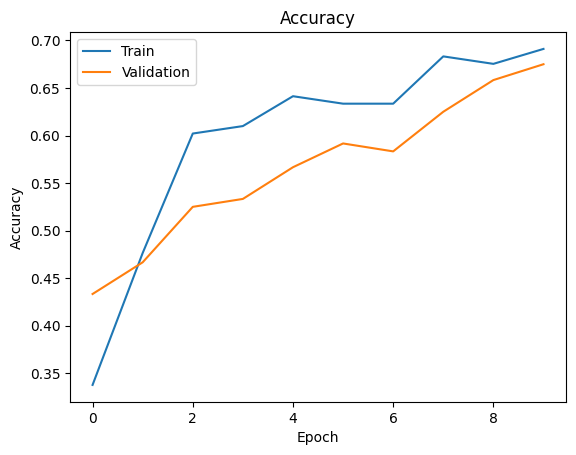

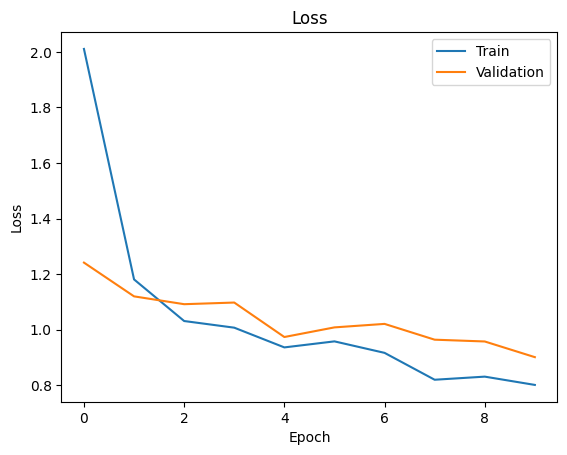

In [32]:
# Accuracy graph
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()

# Loss graph
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train', 'Validation'])
plt.show()

In [33]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

if train_acc > val_acc + 0.1:
    print("⚠️ Overfitting detected")
elif train_acc < 0.6 and val_acc < 0.6:
    print("⚠️ Underfitting detected")
else:
    print("✅ Model is well fitted")

✅ Model is well fitted


In [39]:
from google.colab import files
uploaded = files.upload()

Saving download.jfif to download.jfif


In [40]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Get uploaded file name
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224, 224))

# Convert to array
img_array = image.img_to_array(img)

# Expand dimensions (important)
img_array = np.expand_dims(img_array, axis=0)

# Normalize (same as training)
img_array = img_array / 255.0

In [41]:
prediction = model.predict(img_array)

print("Raw Prediction:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Raw Prediction: [[1.2476709e-04 9.0778828e-01 8.4322944e-02 7.7640242e-03]]


In [42]:
class_names = list(train_data.class_indices.keys())

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Class:", predicted_class)

Predicted Class: Normal_Apple


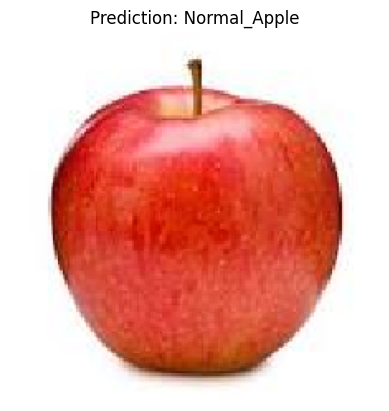

In [43]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Prediction: {predicted_class}")
plt.axis('off')
plt.show()